<font size = "10"><span style="color: red">**I. QTM 151 Final Project**</span>


<font size = "5"><span style="color: lightgrey">Group Members: Tiara Kalan, Mai Vo, Linh Kieu, Jessie Chen</span>

## <span style="color:blue"> II. Introduction </span>

<font size = "4">

Our final project focuses on Formula One data, which encompasses information about Formula One races since 1950. Formula One is a global racing championship where drivers race in extremely advanced, super-fast cars across the world. The cars are open-wheeled, and at the end of the season, trophies are awarded to the best driver and best team. We are interested in the factors that contribute to the success in Formula One racing. Specifically, our research question is: What driver level factors are most associated with race success in Formula One? 

The definition of success will be accounted by the points earned at the end of the season. In order to effectively answer our research question, we will be pulling data from the Drivers, Results, Status, Constructors, and Races datasets. 

The explanatory variables that we are intested in are:
- the driver's age
- the driver's fastest lap time
- the driver's finished position
- the driver's grid position
- rate at which the driver finishes races
- the driver's podium count. 

Intuitively, we expect that age, finished position, rate of finishing races, and grid position exihibit an inverse relationship with the response variable, and the fastest lap time and podium count exhibit a direct relationship with the response variable. Furthermore, we will begin our data analysis through merging the selected datasets into one dataframe in order to compile all necessary information into one source. We plan on cleaning the assembled dataframe to eliminate any unwanted observations and modify the format of observations to ease the analysis process. Lastly, we will visualize our cleaned explanatory variables against the response varibale to identify any trends. Overall, our project shows that consistency and driver skill are most associated with race success in Formula One.

Formula One is increasing in popularity as this racing competition is not only sports, but also engineering and strategy. Races can be heart pounding with breathtaking overtakes to split-second pit-stop battles. Ultimately, Formula One is a global sensation that is not just a competition - it captivates fans of all kinds, including us. 

In [50]:
import pandas as pd 
import numpy as np 
from datetime import datetime 
import matplotlib.pyplot as plt 
import os 

## <span style="color:blue"> III. Data Description </span>

<font size = "4">

As explained in the introduction, we are extrapolating data from the following five datasets. 
- The drivers dataset contains information about each driver competing in the Formula One races. This dataset is indexed by the driverID and contains 9 columns along with 855 observations. 
- The results dataset contains information on the results of the races. This dataset is indexed by resultID and contains 18 columns and 25.7k observations. 
- The third dataset that we aim to explore is the constructors dataset, which entails information on the teams competing in the Formula One races. This dataset is indexed by the constructorID and contains 5 columns and 214 observations. 
- Fourthly, the races dataset contains information on the races that have taken place since 1950. This dataset is indexed by raceID and contains 18 columns and 1096 observations. 
- Lastly, the status dataset contans information about the status of the formula one races. This dataset is indexed by status ID and contains 2 columns and 141 observations. The status of a race refers to the outcome, which encompasses a plethora of possibilties such as the race finishing or that there was an accident.

In [51]:
drivers = pd.read_csv("/Users/maivo/Documents/GitHub/qtm151fall2025/1-Formula_One/drivers.csv")
results = pd.read_csv("/Users/maivo/Documents/GitHub/qtm151fall2025/1-Formula_One/results.csv")
constructors = pd.read_csv("/Users/maivo/Documents/GitHub/qtm151fall2025/1-Formula_One/constructors.csv")
races = pd.read_csv("/Users/maivo/Documents/GitHub/qtm151fall2025/1-Formula_One/races.csv")
status = pd.read_csv("/Users/maivo/Documents/GitHub/qtm151fall2025/1-Formula_One/status.csv")


<font size = "4">

In order to combine these five datasets into one dataframe, we merge the observations together. Intially, we merge the results and races dataset together through their shared column "raceId." The matching "year" and "date" columns based on raceID from the races dataset are also added to the primary dataset. The merged outcome is saved as a Pandas Dataframe object, named "df". Next, the new dataframe, "df", and the drivers dataset are merged based on their commanility of the driverID column. The corresponding "forename", "surname", "dob", and "nationaility" columns based on driverID are also added into the "df" dataframe. The "df" dataframe and constructors dataset share the "constructorID" column, from which these two datasets can be merged along with the corresponding "constructor_name" and "nationality" columns in the constructors dataset. Lastly, the shared "statusID" column allows us to merge the status dataset to the main "df" dataframe, bringing in all the corresponding columns in the status dataset to the primary "df" dataframe. 

Furthermore, some columns in "df" are converted into numeric objects or more suitable formats. The columns of interest are saved in a new dataframe, named "df_clean".

In [52]:
df = results.merge(races[["raceId", "year", "date"]], on="raceId", how="left")

df = df.merge(
    drivers[["driverId", "forename", "surname", "dob", "nationality"]],
    on="driverId", how="left"
)

df = df.merge(
    constructors[["constructorId", "name", "nationality"]]
    .rename(columns={"name":"constructor_name"}),
    on="constructorId", how="left"
)

df = df.merge(status, on="statusId", how="left")

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['dob']  = pd.to_datetime(df['dob'],  errors='coerce')

df["points"] = pd.to_numeric(df["points"], errors="coerce")
df["grid"] = pd.to_numeric(df["grid"], errors="coerce")
df["position"] = pd.to_numeric(df["position"], errors="coerce")
df["fastestLapSpeed"] = pd.to_numeric(df["fastestLapSpeed"], errors="coerce")

df["finished"] = df["status"].str.contains("Finished|Lap", case=False, na=False)

df["age_at_race"] = (df["date"] - df["dob"]).dt.days / 365.25

df_clean = df[[
    "raceId", "year", "date",
    "driverId", "forename", "surname", "age_at_race",
    "constructorId", "constructor_name",
    "grid", "position", "points",
    "fastestLapSpeed",
    "status", "finished"
]]


<font size = "4">

Next, we continue to clean the df_clean dataframe by only keeping observations with results from the year 1990 and onward to ensure a modern-era comparison. Furthermore, we filter out the podium observations that did not finsih within the top three positions. Df_clean is then grouped by the driverId, forename, surname, and year the race took place to compute aggregated performance metrics such as the sum of the season points, average age, average fastest lap, average finish position, finish rate, average grid position, and sum of podiums for each driver. The aggregated performance metrics are saved in a new Pandas Dataframe object named "season_df." All visualizations and further analyses will refer to this cleaned and summarized dataset.

In the "season_df" dataframe, the main columns are driverId, forename, surname, year, season_points, avg_age, avg_fastest_lap, avg_finsih position, finsih_rate, avg_grid_position, and podium_count. DriverId, forename, surname, and year provide context of the drivers and the years they raced. Season_points is our response variable and respresents the total point that each driver earned across all races in the season. Avg_age is our first explanatory variable and represents the driver's mean age at each race. Avg_fastest_lap is our second explanatory variable and marks the fastest mean time that each driver takes to complete one lap. Avg_finish_position and avg_grid_position are our third and fourth explanatory variables, and they reflect the typical finishing and starting positions of each driver, respectively. Our fifth explanatory variable is finsih_rate, and this column consists of the porportion of races that the driver successfully completed. Lastly, podium_count sums up the total amount of times each driver finished the race in the top three. 

In [53]:
df_clean = df_clean[df_clean["year"] >= 1990]
df_clean["podium"] = df_clean["position"] <= 3

season_df = (
    df_clean
    .groupby(["driverId", "forename", "surname", "year"], as_index=False)
    .agg(
        season_points=("points", "sum"),
        avg_age=("age_at_race", "mean"),
        avg_fastest_lap=("fastestLapSpeed", "mean"),
        avg_finish_position=("position", "mean"),
        finish_rate=("finished", "mean"),
        avg_grid_position=("grid", "mean"),
        podium_count=("podium", "sum") 
    )
)

print(season_df.head())

   driverId forename   surname  year  season_points    avg_age  \
0         1    Lewis  Hamilton  2007          109.0  22.507066   
1         1    Lewis  Hamilton  2008           98.0  23.510533   
2         1    Lewis  Hamilton  2009           49.0  24.510368   
3         1    Lewis  Hamilton  2010          240.0  25.513887   
4         1    Lewis  Hamilton  2011          227.0  26.547786   

   avg_fastest_lap  avg_finish_position  finish_rate  avg_grid_position  \
0       207.627941             3.000000     0.941176           2.588235   
1       204.564667             4.411765     0.944444           3.888889   
2       201.310250             7.642857     0.764706           9.176471   
3       200.167389             3.750000     0.789474           5.157895   
4       198.009053             3.750000     0.842105           3.578947   

   podium_count  
0            12  
1            10  
2             5  
3             9  
4             6  


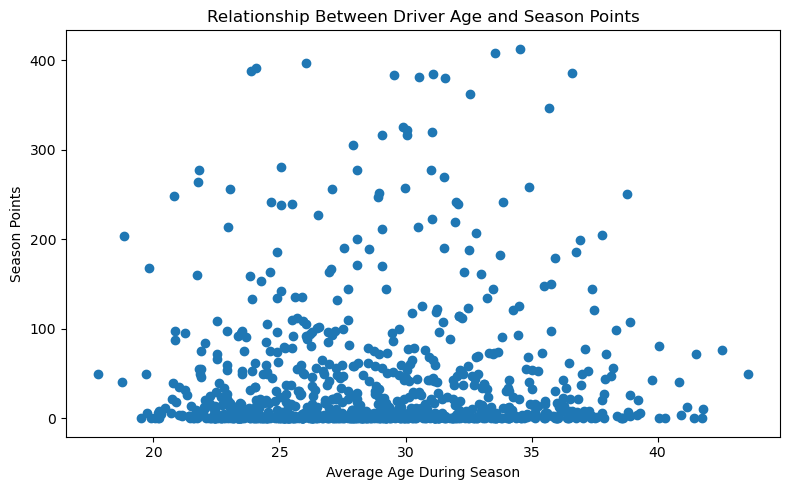

In [54]:
plt.figure(figsize=(8,5))
plt.scatter(season_df["avg_age"], season_df["season_points"])
plt.xlabel("Average Age During Season")
plt.ylabel("Season Points")
plt.title("Relationship Between Driver Age and Season Points")
plt.tight_layout()
plt.show()

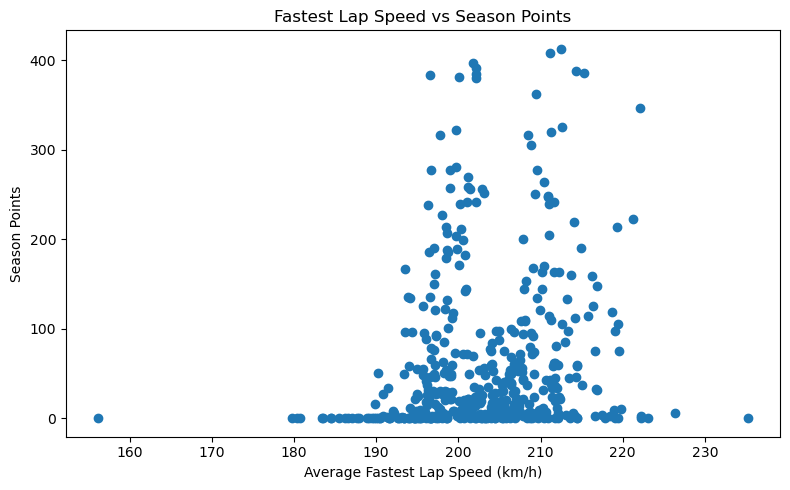

In [55]:
plt.figure(figsize=(8,5))
plt.scatter(season_df["avg_fastest_lap"], season_df["season_points"])
plt.xlabel("Average Fastest Lap Speed (km/h)")
plt.ylabel("Season Points")
plt.title("Fastest Lap Speed vs Season Points")
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

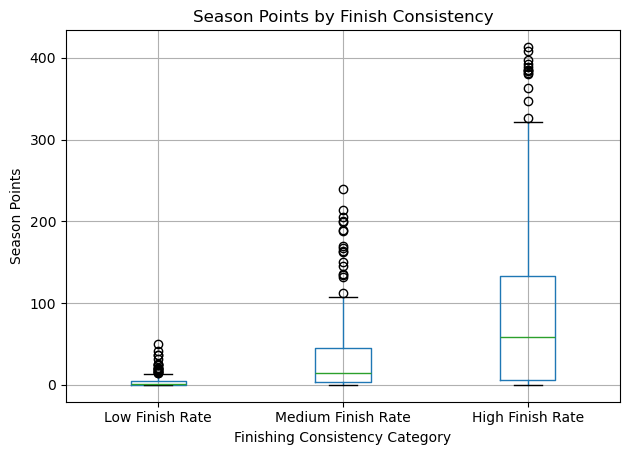

In [56]:
season_df["finish_cat"] = pd.cut(
    season_df["finish_rate"],
    bins=[0, 0.5, 0.8, 1.0],
    labels=["Low Finish Rate", "Medium Finish Rate", "High Finish Rate"]
)

plt.figure(figsize=(8,5))
season_df.boxplot(column="season_points", by="finish_cat")
plt.suptitle("")
plt.xlabel("Finishing Consistency Category")
plt.ylabel("Season Points")
plt.title("Season Points by Finish Consistency")
plt.tight_layout()
plt.show()

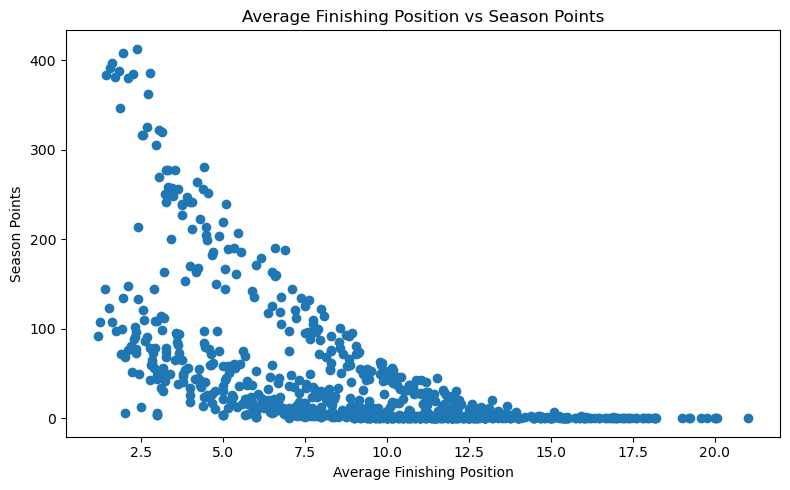

In [57]:
plt.figure(figsize=(8,5))
plt.scatter(season_df["avg_finish_position"], season_df["season_points"])
plt.xlabel("Average Finishing Position")
plt.ylabel("Season Points")
plt.title("Average Finishing Position vs Season Points")
plt.tight_layout()
plt.show()

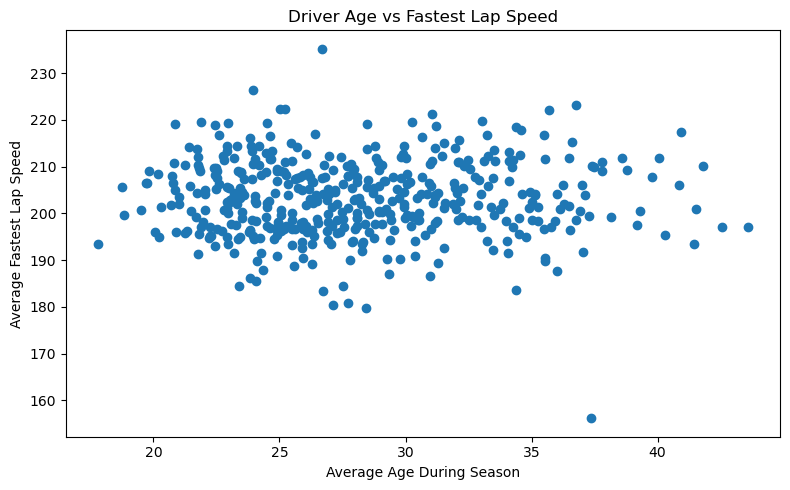

In [58]:
plt.figure(figsize=(8,5))
plt.scatter(season_df["avg_age"], season_df["avg_fastest_lap"])
plt.xlabel("Average Age During Season")
plt.ylabel("Average Fastest Lap Speed")
plt.title("Driver Age vs Fastest Lap Speed")
plt.tight_layout()
plt.show()

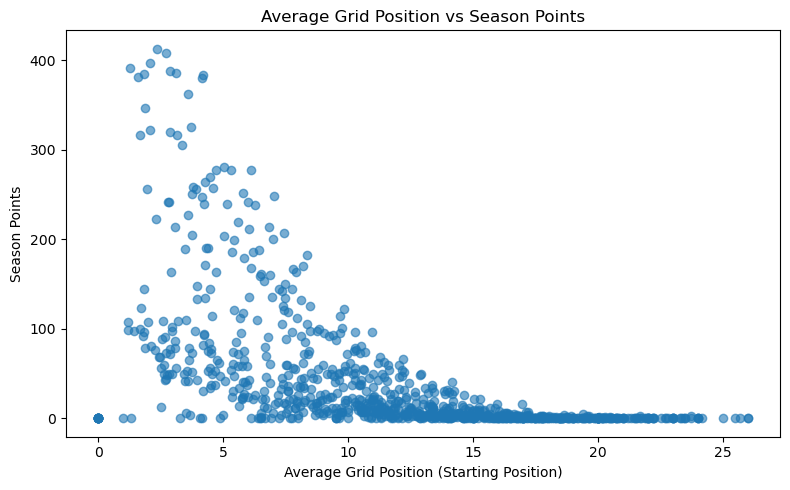

In [59]:
plt.figure(figsize=(8,5))
plt.scatter(season_df["avg_grid_position"], season_df["season_points"], alpha=0.6)
plt.xlabel("Average Grid Position (Starting Position)")
plt.ylabel("Season Points")
plt.title("Average Grid Position vs Season Points")
plt.tight_layout()
plt.show()

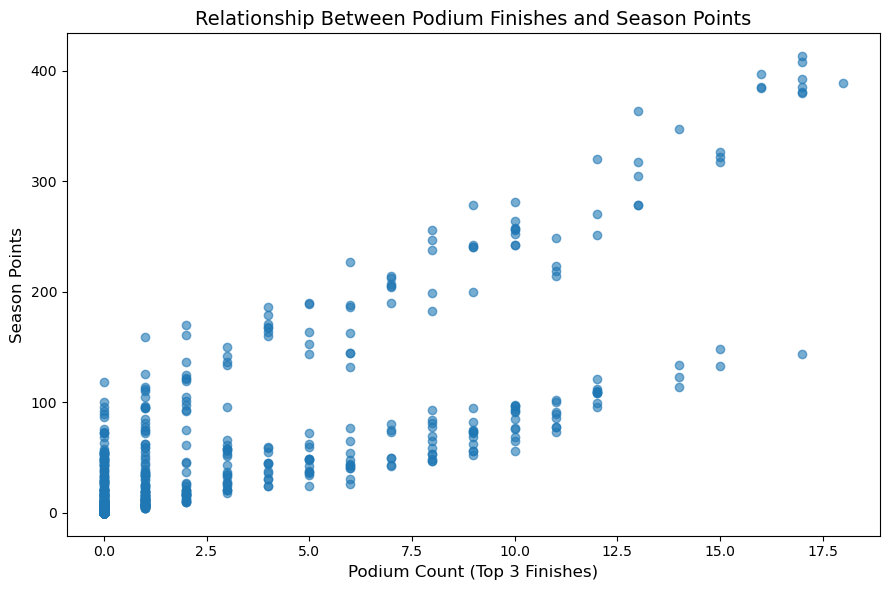

In [60]:
plt.figure(figsize=(9,6))
plt.scatter(
    season_df["podium_count"],
    season_df["season_points"],
    alpha=0.6,
)

plt.xlabel("Podium Count (Top 3 Finishes)", fontsize=12)
plt.ylabel("Season Points", fontsize=12)
plt.title("Relationship Between Podium Finishes and Season Points", fontsize=14)

plt.tight_layout()
plt.show()
